# Analisis Performa Tim dan Strategi Pit Stop Formula 1 Era Turbo-Hybrid (2014-2021) Menggunakan Pendekatan Object-Oriented Programming Python

In [ ]:
!pip install pandas numpy matplotlib kagglehub seaborn

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Pengumpulan Data (Data Collection)

Bagian ini berfokus pada pengumpulan data pit stop Formula 1 yang diperlukan dari sumbernya, memastikan semua file mentah diunduh dan siap untuk diperiksa dan dipilih.

In [ ]:
class Collection:
    def __init__(self, datasource):
        self.datasource = datasource
        self.path = None
        self.raw_files = []
        self.datasets = {}

    def load_dataset(self):
        print(" Mengunduh berkas mentah dari Kaggle...")
        self.path = kagglehub.dataset_download(self.datasource)
        print(f" Berkas berhasil dikumpulkan di: {self.path}")

        self.raw_files = os.listdir(self.path)
        print(f"Jumlah dataset : {len(self.raw_files)} file.")
        print(f"List dataset : {self.raw_files}")

    def dataset_features(self, target_file):
      for file in target_file:
        if file in self.raw_files:
            file_path = os.path.join(self.path, file)
            temp_df = pd.read_csv(file_path, nrows=5)

            print(f"FITUR FILE: {file}")
            print(temp_df.info())
            print("----"*50)

    def select_dataset(self, selected_list):
        for file_name in selected_list:
            if file_name in self.raw_files:
                file_path = os.path.join(self.path, file_name)
                self.datasets[file_name] = pd.read_csv(file_path)
                print(f" Variabel Terpilih Berhasil Menyimpan: '{file_name}' (Shape: {self.datasets[file_name].shape})")

In [ ]:
DATASOURCE = "rohanrao/formula-1-world-championship-1950-2020"

f1_collection = Collection(DATASOURCE)

f1_collection.load_dataset()


 Mengunduh berkas mentah dari Kaggle...
Using Colab cache for faster access to the 'formula-1-world-championship-1950-2020' dataset.
 Berkas berhasil dikumpulkan di: /kaggle/input/formula-1-world-championship-1950-2020
Jumlah dataset : 14 file.
List dataset : ['races.csv', 'constructor_results.csv', 'drivers.csv', 'constructors.csv', 'lap_times.csv', 'status.csv', 'driver_standings.csv', 'seasons.csv', 'pit_stops.csv', 'sprint_results.csv', 'constructor_standings.csv', 'results.csv', 'circuits.csv', 'qualifying.csv']


In [ ]:
f1_collection.dataset_features(['races.csv', 'constructor_results.csv', 'drivers.csv', 'constructors.csv', 'lap_times.csv', 'status.csv', 'driver_standings.csv', 'seasons.csv', 'pit_stops.csv', 'sprint_results.csv', 'constructor_standings.csv', 'results.csv', 'circuits.csv', 'qualifying.csv'])

DATA_TERPILIH = ["races.csv", "pit_stops.csv", "results.csv", "circuits.csv", "drivers.csv", "constructors.csv"]
f1_collection.select_dataset(DATA_TERPILIH)

FITUR FILE: races.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   raceId       5 non-null      int64 
 1   year         5 non-null      int64 
 2   round        5 non-null      int64 
 3   circuitId    5 non-null      int64 
 4   name         5 non-null      object
 5   date         5 non-null      object
 6   time         5 non-null      object
 7   url          5 non-null      object
 8   fp1_date     5 non-null      object
 9   fp1_time     5 non-null      object
 10  fp2_date     5 non-null      object
 11  fp2_time     5 non-null      object
 12  fp3_date     5 non-null      object
 13  fp3_time     5 non-null      object
 14  quali_date   5 non-null      object
 15  quali_time   5 non-null      object
 16  sprint_date  5 non-null      object
 17  sprint_time  5 non-null      object
dtypes: int64(4), object(14)
memory usage: 852.0+ bytes
N

## 2. Pembersihan Data (Data Cleaning)

Bagian ini menangani prapemrosesan awal data yang telah dikumpulkan. Ini melibatkan penghapusan kolom yang tidak relevan, standardisasi nilai, serta penanganan duplikat dan entri yang hilang di seluruh dataset individual.

In [ ]:
class Cleaning:
    def __init__(self, global_datasets):
        self.datasets = {key: df.copy() for key, df in global_datasets.items()}

    def remove_unselected_columns(self, columns_to_drop):
        for file_name, cols in columns_to_drop.items():
            if file_name in self.datasets:
                self.datasets[file_name].drop(columns=cols, errors="ignore", inplace=True)
                print(f" File '{file_name}': Kolom berhasil dibuang.")

    def convert_invalid_strings(self):
        for file_name in self.datasets:
            self.datasets[file_name].replace(r"^\\N$", np.nan, regex=True, inplace=True)
        print("Standarisasi Berhasil")

In [ ]:
class CleaningEachFiles(Cleaning):
    def __init__(self, global_datasets):
        super().__init__(global_datasets)

    def check_and_remove_duplicates(self):
        for file_name in self.datasets:
            self.datasets[file_name].drop_duplicates(inplace=True)
        print("Data duplikat telah dibersihkan.")

    def handle_missing_values(self):
        for file_name in self.datasets:
            df = self.datasets[file_name]
            null_columns = df.columns[df.isnull().any()].tolist()
            for col in null_columns:
                if pd.api.types.is_numeric_dtype(df[col]):
                    df[col].fillna(0, inplace=True)
                else:
                    df[col].fillna("unknown", inplace=True)

    def file_feature_engineering(self):
        if "pit_stops.csv" in self.datasets:
            df_pit = self.datasets["pit_stops.csv"]
            if "milliseconds" in df_pit.columns:
                df_pit["pit_duration_sec"] = df_pit["milliseconds"] / 1000.0
            df_pit.head(5)

        for file_name in self.datasets:
            df = self.datasets[file_name]
            for col in df.select_dtypes(include="object").columns:
                df[col] = df[col].astype(str).str.lower().str.strip()

In [ ]:
DROP_MAP = {
    "races.csv": ["url", "fp1_date", "fp1_time", "fp2_date", "fp2_time", "fp3_date", "fp3_time", "quali_date", "quali_time", "sprint_date", "sprint_time", "time"],
    "circuits.csv": ["circuitRef", "url", "lat", "lng", "alt"],
    "results.csv": ["resultId", "number", "position", "positionText", "time", "fastestLapTime", "fastestLapSpeed", "fastestLap"],
    "drivers.csv": ["driverRef", "number", "code", "dob", "url"],
    "constructors.csv": ["constructorRef", "url"]
}

f1_cleaning = CleaningEachFiles(f1_collection.datasets)

f1_cleaning.remove_unselected_columns(DROP_MAP)
f1_cleaning.convert_invalid_strings()
f1_cleaning.check_and_remove_duplicates()
f1_cleaning.handle_missing_values()
f1_cleaning.file_feature_engineering()


 File 'races.csv': Kolom berhasil dibuang.
 File 'circuits.csv': Kolom berhasil dibuang.
 File 'results.csv': Kolom berhasil dibuang.
 File 'drivers.csv': Kolom berhasil dibuang.
 File 'constructors.csv': Kolom berhasil dibuang.
Standarisasi Berhasil
Data duplikat telah dibersihkan.


/tmp/ipykernel_3030/4123745815.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("unknown", inplace=True)


In [ ]:
for nama_file, df_bersih in f1_cleaning.datasets.items():
    print(f"File: {nama_file} | Ukuran Terbaru: {df_bersih.shape}")

File: races.csv | Ukuran Terbaru: (1125, 6)
File: pit_stops.csv | Ukuran Terbaru: (11371, 8)
File: results.csv | Ukuran Terbaru: (26759, 10)
File: circuits.csv | Ukuran Terbaru: (77, 4)
File: drivers.csv | Ukuran Terbaru: (861, 4)
File: constructors.csv | Ukuran Terbaru: (212, 3)


In [ ]:
# Mengintip 5 baris teratas dari data pit stop yang sudah bersih
f1_cleaning.datasets["pit_stops.csv"].head()

,raceId,driverId,stop,lap,time,duration,milliseconds,pit_duration_sec
0,841,153,1,1,17:05:23,26.898,26898,26.898
1,841,30,1,1,17:05:52,25.021,25021,25.021
2,841,17,1,11,17:20:48,23.426,23426,23.426
3,841,4,1,12,17:22:34,23.251,23251,23.251
4,841,13,1,13,17:24:10,23.842,23842,23.842


## 3. Penggabungan Data (Data Merging)

Dalam bagian ini, semua dataset individual yang telah dibersihkan digabungkan menjadi satu DataFrame master yang komprehensif. Proses ini melibatkan penggabungan data berdasarkan kunci relasional umum untuk menciptakan tampilan terpadu dari peristiwa pit stop, hasil balapan, informasi pembalap, dan detail konstruktor.

In [ ]:
class Merge:
    def __init__(self, cleaned_datasets):
        self.datasets = cleaned_datasets
        self.final_df = None

    def merge_all_datasets(self):
        print("--- [STARTING MERGE PROCESS] ---")
        print(" Menghubungkan 'results.csv' dengan 'pit_stops.csv'...")
        master = pd.merge(
            self.datasets["results.csv"],
            self.datasets["pit_stops.csv"],
            on=["raceId", "driverId"],
            how="inner"
        )
        print(f"   -> Ukuran setelah gabungan awal: {master.shape}")

        if "races.csv" in self.datasets:
            print(" Menghubungkan dengan 'races.csv'...")
            master = pd.merge(master, self.datasets["races.csv"], on="raceId", how="left")

        if "drivers.csv" in self.datasets:
            print(" Menghubungkan dengan 'drivers.csv'...")
            df_drivers = self.datasets["drivers.csv"].copy()
            if "name" in df_drivers.columns:
                df_drivers.rename(columns={"name": "driver_name"}, inplace=self)
            master = pd.merge(master, df_drivers, on="driverId", how="left")

        if "constructors.csv" in self.datasets:
            print(" Menghubungkan dengan 'constructors.csv'...")
            df_const = self.datasets["constructors.csv"].copy()
            if "name" in df_const.columns:
                df_const.rename(columns={"name": "constructor_name"}, inplace=True)
            master = pd.merge(master, df_const, on="constructorId", how="left")

        if "circuits.csv" in self.datasets:
            print(" Menghubungkan dengan 'circuits.csv'...")
            df_circ = self.datasets["circuits.csv"].copy()
            if "name" in df_circ.columns:
                df_circ.rename(columns={"name": "circuit_name"}, inplace=True)
            master = pd.merge(master, df_circ, on="circuitId", how="left")

        self.final_df = master
        print("---"*50)
        print(f" Ukuran Akhir: {self.final_df.shape}")

    def show_merged_preview(self, n=5):
        if self.final_df is not None:
            return self.final_df.head(n)

In [ ]:
f1_merge = Merge(f1_cleaning.datasets)
f1_merge.merge_all_datasets()
f1_merge.show_merged_preview()

--- [STARTING MERGE PROCESS] ---
 Menghubungkan 'results.csv' dengan 'pit_stops.csv'...
   -> Ukuran setelah gabungan awal: (11371, 16)
 Menghubungkan dengan 'races.csv'...
 Menghubungkan dengan 'drivers.csv'...
 Menghubungkan dengan 'constructors.csv'...
 Menghubungkan dengan 'circuits.csv'...
------------------------------------------------------------------------------------------------------------------------------------------------------
 Ukuran Akhir: (11371, 29)


,raceId,driverId,constructorId,grid,positionOrder,points,laps,milliseconds_x,rank,statusId,...,name,date,forename,surname,nationality_x,constructor_name,nationality_y,circuit_name,location,country
0,841,20,9,1,1,25.0,58,5370259,4,1,...,australian grand prix,2011-03-27,sebastian,vettel,german,red bull,austrian,albert park grand prix circuit,melbourne,australia
1,841,20,9,1,1,25.0,58,5370259,4,1,...,australian grand prix,2011-03-27,sebastian,vettel,german,red bull,austrian,albert park grand prix circuit,melbourne,australia
2,841,1,1,2,2,18.0,58,5392556,8,1,...,australian grand prix,2011-03-27,lewis,hamilton,british,mclaren,british,albert park grand prix circuit,melbourne,australia
3,841,1,1,2,2,18.0,58,5392556,8,1,...,australian grand prix,2011-03-27,lewis,hamilton,british,mclaren,british,albert park grand prix circuit,melbourne,australia
4,841,808,4,6,3,15.0,58,5400819,7,1,...,australian grand prix,2011-03-27,vitaly,petrov,russian,renault,french,albert park grand prix circuit,melbourne,australia


## 4. Persiapan Data (Data Preparation)

Bagian ini menyiapkan dataset master yang telah digabungkan untuk analisis. Ini mencakup pemfilteran data untuk era Turbo-Hybrid, rekayasa fitur lanjutan (seperti skor efisiensi pit), penanganan tugas pembersihan pasca-penggabungan, dan visualisasi serta penghapusan outlier untuk memastikan kualitas dan relevansi data.

In [ ]:
class Preparation:
    def __init__(self, merged_df):
        self.df = merged_df.copy()
        self.final_dataset = None

    def filter_turbo_hybrid_era(self):
        print("--- [PREP: FILTERING TURBO-HYBRID ERA] ---")
        if 'year' in self.df.columns:
            self.df = self.df[(self.df['year'] >= 2014) & (self.df['year'] <= 2021)]
            print(f" Sukses! Data difilter untuk tahun {self.df['year'].min()} - {self.df['year'].max()}")
            print(f" Ukuran data saat ini: {self.df.shape}")

    def advanced_feature_engineering(self):
        print("--- [PREP: FEATURE ENGINEERING & RENAME] ---")
        if 'points' in self.df.columns and 'pit_duration_sec' in self.df.columns:
            self.df['pit_efficiency_score'] = (self.df['points'] + 1) / self.df['pit_duration_sec']
            print(" Sukses membuat fitur baru: 'pit_efficiency_score'")

        if 'name' in self.df.columns:
            self.df.rename(columns={'name': 'race_name'}, inplace=True)
            print(" Sukses merename kolom 'name' -> 'race_name'")

    def handle_post_merge_clean(self):
        print("--- [PREP: POST-MERGE CLEANING & COLUMN DROPPING] ---")
        cols_to_drop = ['milliseconds_x', 'milliseconds_y', 'duration', 'nationality_y']
        before_cols = len(self.df.columns)
        self.df.drop(columns=cols_to_drop, errors="ignore", inplace=True)
        after_cols = len(self.df.columns)
        print(f" Berhasil membuang {before_cols - after_cols} kolom sisa/duplikat ({cols_to_drop}).")

        before_dup = self.df.duplicated().sum()
        if before_dup > 0:
            self.df.drop_duplicates(inplace=True)
            print(f"Menghapus {before_dup} data duplikat baris hasil merge.")

        null_cols = self.df.columns[self.df.isnull().any()].tolist()
        if null_cols:
            for col in null_cols:
                if pd.api.types.is_numeric_dtype(self.df[col]):
                    self.df[col] = self.df[col].fillna(0)
                else:
                    self.df[col] = self.df[col].fillna("unknown")
            print(f" Sukses membersihkan missing values pada kolom sisa: {null_cols}")

    def remove_outliers(self, column='pit_duration_sec'):
        print(f"[PREP: OUTLIER REMOVAL & VISUALIZATION ON {column}]")

        df_before = self.df.copy()
        jumlah_sebelum = len(df_before)

        Q1 = self.df[column].quantile(0.25)
        Q3 = self.df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        self.df = self.df[(self.df[column] >= lower_bound) & (self.df[column] <= upper_bound)]
        df_after = self.df.copy()
        jumlah_sesudah = len(df_after)

        jumlah_outlier = jumlah_sebelum - jumlah_sesudah

        print(f" RINGKASAN FILTER OUTLIER [{column}]:")
        print(f"   • Data Sebelum Remove Outlier : {jumlah_sebelum} baris")
        print(f"   • Jumlah Outlier Terdeteksi   : {jumlah_outlier} baris")
        print(f"   • Data Setelah Remove Outlier  : {jumlah_sesudah} baris")
        print(f"   • Efisiensi Data Bersih       : {(jumlah_sesudah/jumlah_sebelum)*100:.2f}%")


        #Visualisasi
        fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 22))
        fig.suptitle(f'Comprehensive Outlier Impact Analysis on [{column}]', fontsize=22, fontweight='bold', y=0.98)

        # BARIS 1: BOXPLOT
        sns.boxplot(data=df_before, x=column, ax=axes[0, 0], color="salmon")
        axes[0, 0].set_title(f'{column} - Before Outlier Removal (Boxplot)', fontsize=12)

        sns.boxplot(data=df_after, x=column, ax=axes[0, 1], color="lightgreen")
        axes[0, 1].set_title(f'{column} - After Outlier Removal (Boxplot)', fontsize=12)

        # BARIS 2: HISTOGRAM
        sns.histplot(data=df_before, x=column, kde=True, ax=axes[1, 0], color="salmon")
        axes[1, 0].set_title(f'{column} - Before Outlier Removal (Histogram)', fontsize=12)

        sns.histplot(data=df_after, x=column, kde=True, ax=axes[1, 1], color="lightgreen")
        axes[1, 1].set_title(f'{column} - After Outlier Removal (Histogram)', fontsize=12)

        # BARIS 3: SCATTER PLOT
        axes[2, 0].scatter(range(len(df_before)), df_before[column], alpha=0.4, color="salmon")
        axes[2, 0].set_title(f'{column} - Before Outlier Removal (Scatter Spread)', fontsize=12)
        axes[2, 0].set_xlabel('Data Index')
        axes[2, 0].set_ylabel(column)

        axes[2, 1].scatter(range(len(df_after)), df_after[column], alpha=0.4, color="lightgreen")
        axes[2, 1].set_title(f'{column} - After Outlier Removal (Scatter Spread)', fontsize=12)
        axes[2, 1].set_xlabel('Data Index')
        axes[2, 1].set_ylabel(column)

        # BARIS 4: VIOLIN PLOT
        sns.violinplot(data=df_before, x=column, ax=axes[3, 0], color="salmon")
        axes[3, 0].set_title(f'{column} - Before Outlier Removal (Violin)', fontsize=12)

        sns.violinplot(data=df_after, x=column, ax=axes[3, 1], color="lightgreen")
        axes[3, 1].set_title(f'{column} - After Outlier Removal (Violin)', fontsize=12)

        plt.tight_layout(rect=[0, 0.02, 1, 0.96])
        plt.show()

    def get_final_dataset(self):
        self.final_dataset = self.df.reset_index(drop=True)
        print(self.final_dataset.info())
        return self.final_dataset

--- [PREP: FILTERING TURBO-HYBRID ERA] ---
 Sukses! Data difilter untuk tahun 2014 - 2021
 Ukuran data saat ini: (5818, 29)
--- [PREP: FEATURE ENGINEERING & RENAME] ---
 Sukses membuat fitur baru: 'pit_efficiency_score'
 Sukses merename kolom 'name' -> 'race_name'
--- [PREP: POST-MERGE CLEANING & COLUMN DROPPING] ---
 Berhasil membuang 4 kolom sisa/duplikat (['milliseconds_x', 'milliseconds_y', 'duration', 'nationality_y']).
[PREP: OUTLIER REMOVAL & VISUALIZATION ON pit_duration_sec]
 RINGKASAN FILTER OUTLIER [pit_duration_sec]:
   • Data Sebelum Remove Outlier : 5818 baris
   • Jumlah Outlier Terdeteksi   : 432 baris
   • Data Setelah Remove Outlier  : 5386 baris
   • Efisiensi Data Bersih       : 92.57%


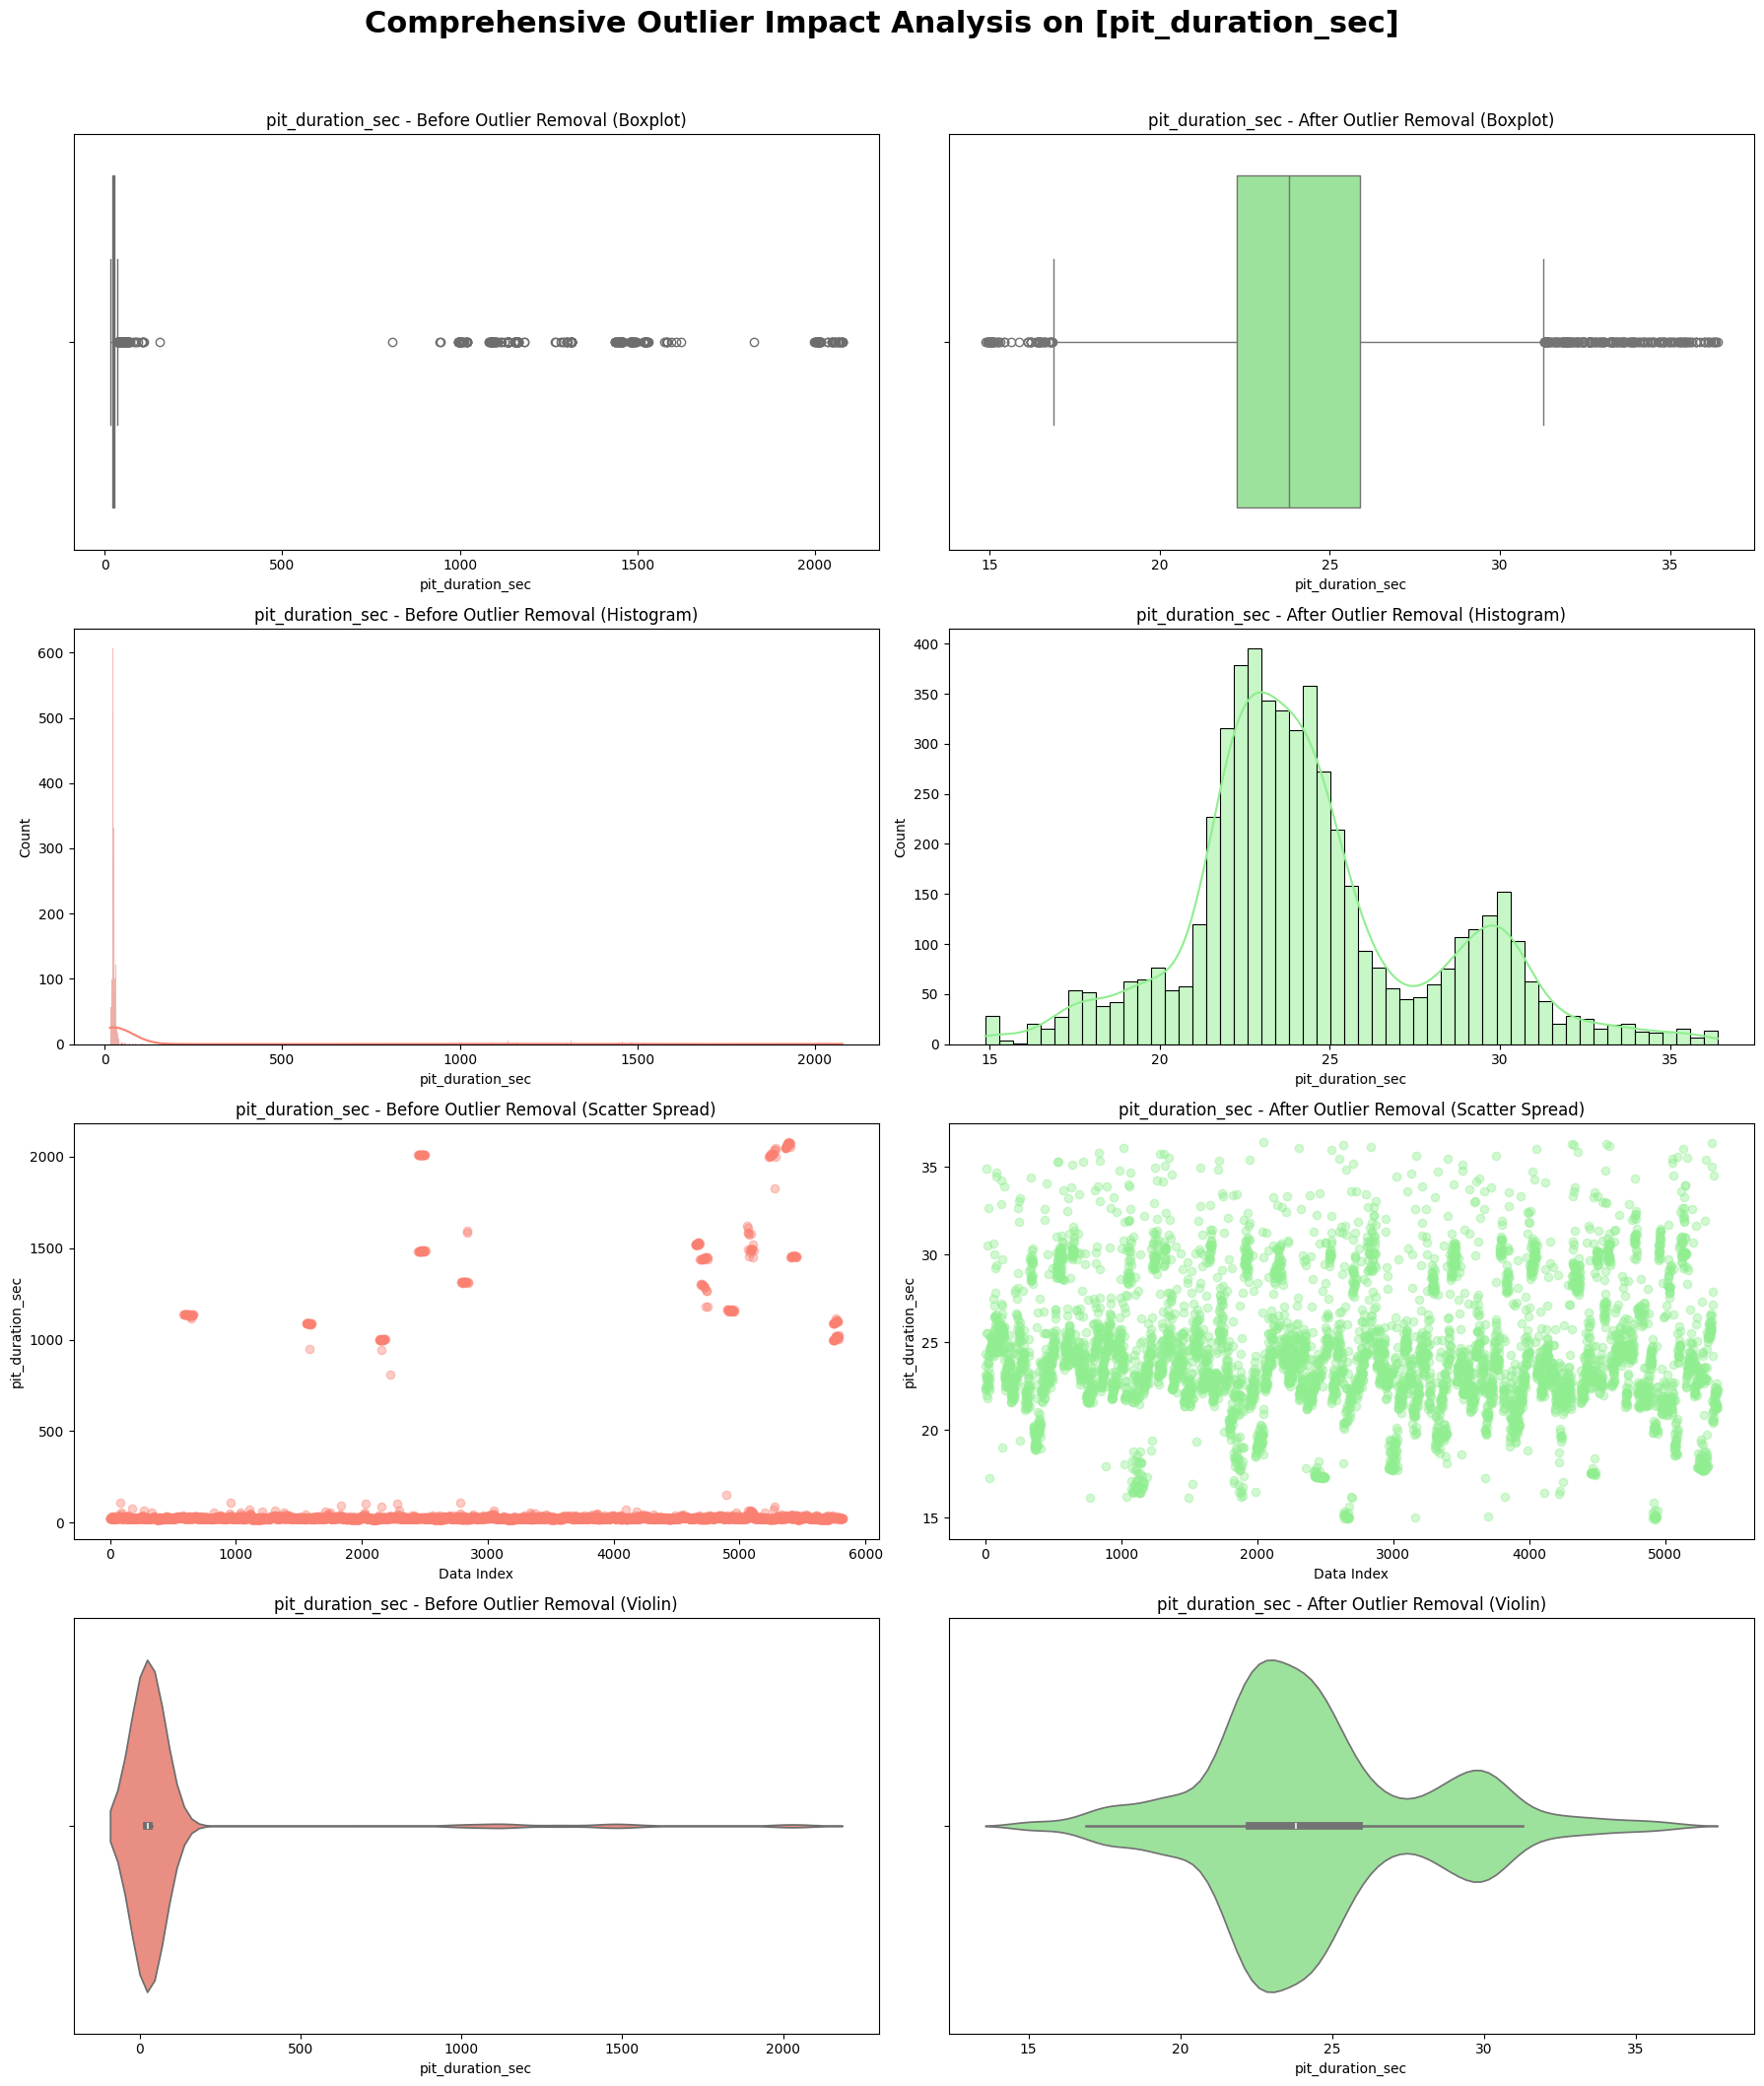

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5386 entries, 0 to 5385
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   raceId                5386 non-null   int64  
 1   driverId              5386 non-null   int64  
 2   constructorId         5386 non-null   int64  
 3   grid                  5386 non-null   int64  
 4   positionOrder         5386 non-null   int64  
 5   points                5386 non-null   float64
 6   laps                  5386 non-null   int64  
 7   rank                  5386 non-null   object 
 8   statusId              5386 non-null   int64  
 9   stop                  5386 non-null   int64  
 10  lap                   5386 non-null   int64  
 11  time                  5386 non-null   object 
 12  pit_duration_sec      5386 non-null   float64
 13  year                  5386 non-null   int64  
 14  round                 5386 non-null   int64  
 15  circuitId            

In [ ]:
f1_prep = Preparation(f1_merge.final_df)

f1_prep.filter_turbo_hybrid_era()
f1_prep.advanced_feature_engineering()

f1_prep.handle_post_merge_clean()

f1_prep.remove_outliers(column='pit_duration_sec')

f1_master = f1_prep.get_final_dataset()

In [ ]:
f1_master.to_csv('F1Dataset.csv', index=False)

print("Extracted")

Extracted


## 5. Algoritma 1: Analisis Performa Tim

**Tujuan:** Mengidentifikasi tim Formula 1 mana yang memiliki performa pit stop terbaik berdasarkan kecepatan, konsistensi, dan perkembangan performa selama era turbo-hybrid.

**Deskripsi:** Bagian ini akan menganalisis data pit stop untuk setiap tim, menghitung metrik statistik seperti median durasi, rata-rata, dan standar deviasi, serta melacak tren perkembangan performa tim dari tahun ke tahun. Visualisasi akan disajikan untuk membandingkan tim-tim teratas.

In [ ]:
df_final_pitstop = f1_master.copy()

,constructor_name,Median,Rata_Rata,Std_Dev,Total_Pitstop,Perkembangan
0,mercedes,23.263,23.880,3.401,549,-1.222
1,red bull,23.300,23.966,3.494,541,-0.618
2,racing point,23.406,24.732,3.602,106,0.304
3,ferrari,23.474,24.169,3.629,531,-1.183
4,aston martin,23.500,24.020,4.084,63,0.000
5,mclaren,23.690,24.157,3.647,516,-0.568
6,alpine f1 team,23.690,24.251,4.201,58,0.000
7,williams,23.736,24.361,3.556,563,-0.762
8,alphatauri,23.745,24.602,3.987,115,0.183
9,renault,23.868,24.356,3.558,295,0.841


year                2014    2015    2016    2017    2018    2019    2020  \
constructor_name                                                           
alfa romeo           NaN     NaN     NaN     NaN     NaN  24.047  24.454   
alphatauri           NaN     NaN     NaN     NaN     NaN     NaN  23.618   
alpine f1 team       NaN     NaN     NaN     NaN     NaN     NaN     NaN   
aston martin         NaN     NaN     NaN     NaN     NaN     NaN     NaN   
caterham          25.412     NaN     NaN     NaN     NaN     NaN     NaN   
ferrari           23.928  24.077  23.056  22.934  23.587  23.613  24.275   
force india       23.902  24.233  23.457  24.030  24.086     NaN     NaN   
haas f1 team         NaN     NaN  23.679  23.964  23.871  23.478  25.786   
lotus f1          24.198  24.196     NaN     NaN     NaN     NaN     NaN   
manor marussia       NaN  25.430  25.201     NaN     NaN     NaN     NaN   
marussia          24.828     NaN     NaN     NaN     NaN     NaN     NaN   
mclaren     

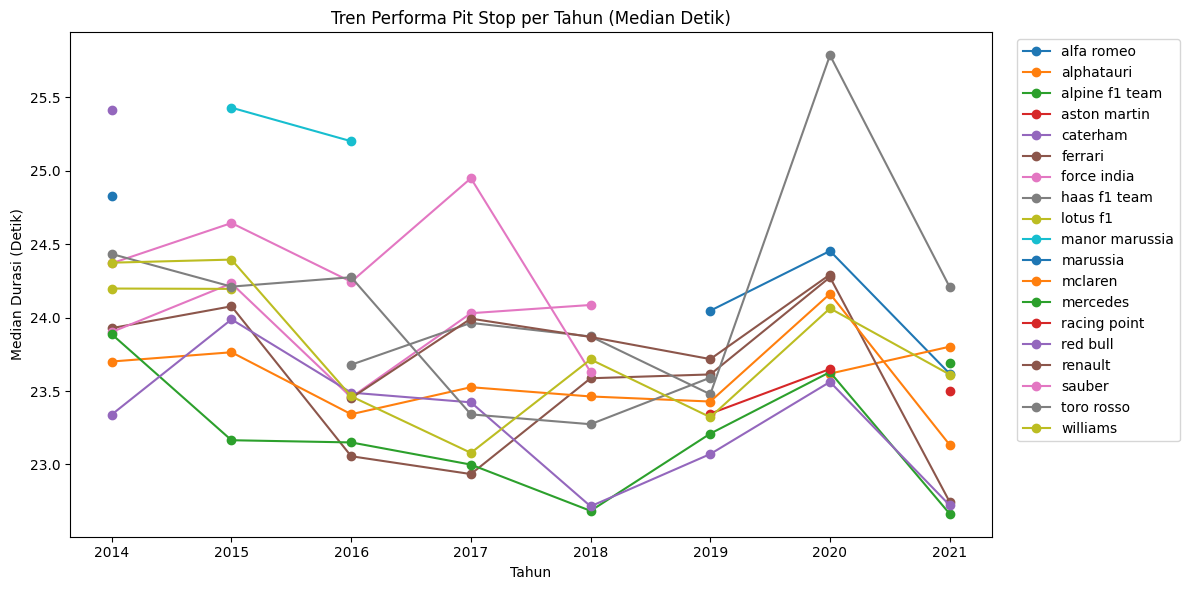

   constructor_name  Rata_Rata
0          mercedes     23.880
1          red bull     23.966
4      aston martin     24.020
5           mclaren     24.157
3           ferrari     24.169
6    alpine f1 team     24.251
9           renault     24.356
7          williams     24.361
12       toro rosso     24.525
10      force india     24.558


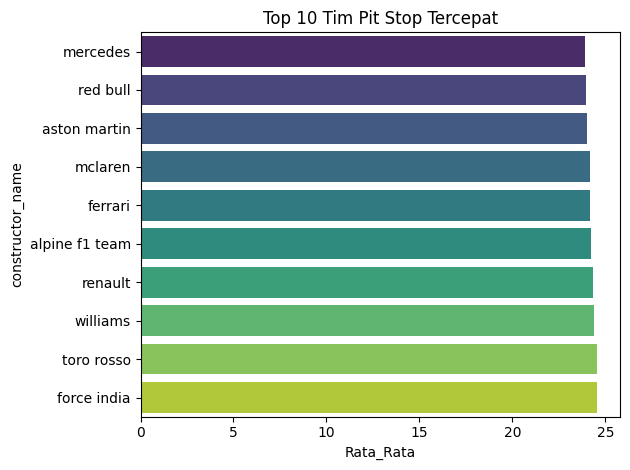

In [ ]:
class TeamPerformanceAnalyzer:
    def __init__(self, df):
        self.df = df

    def ranking(self):
        agg = self.df.groupby('constructor_name')['pit_duration_sec'].agg(Median='median', Rata_Rata='mean', Std_Dev='std', Total_Pitstop='count').round(3)

        trend = self.df.groupby(['constructor_name', 'year'])['pit_duration_sec'].median().unstack()

        def hitung_perkembangan(row):
            valid = row.dropna()
            if len(valid) < 2:
                return 0.0
            return round(valid.iloc[-1] - valid.iloc[0], 3)

        agg['Perkembangan'] = trend.apply(hitung_perkembangan, axis=1)

        self.trend = trend
        return agg.sort_values(['Median', 'Std_Dev']).reset_index()

    def plot_trend(self):
        print(self.trend.round(3))
        self.trend.T.plot(figsize=(12, 6), marker='o')
        plt.title('Tren Performa Pit Stop per Tahun (Median Detik)')
        plt.xlabel('Tahun'); plt.ylabel('Median Durasi (Detik)')
        plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout(); plt.show()

    def plot_top10(self, ranking_df):
        top10 = ranking_df.nsmallest(10, 'Rata_Rata')
        print(top10[['constructor_name', 'Rata_Rata']])
        sns.barplot(x='Rata_Rata', y='constructor_name', data=top10, hue='constructor_name', palette='viridis', legend=False)
        plt.title('Top 10 Tim Pit Stop Tercepat')
        plt.tight_layout(); plt.show()

# Objek
analyzer = TeamPerformanceAnalyzer(f1_master)
ranking = analyzer.ranking()
display(ranking)
analyzer.plot_trend()
analyzer.plot_top10(ranking)

## 6. Algoritma 2: Pengaruh Pit Stop terhadap Hasil Balapan

**Tujuan:** Memahami bagaimana pengaruh performa pit stop terhadap hasil akhir balapan yang diperoleh pembalap dan tim Formula 1.

**Deskripsi:** Bagian ini akan mengeksplorasi korelasi antara durasi pit stop, posisi finis, dan perolehan poin. Ini akan membantu mengetahui apakah pit stop yang lebih cepat cenderung menghasilkan posisi akhir dan poin yang lebih baik untuk pembalap dan tim.

driver_name
paul di resta       22.399
brendon hartley     23.067
lewis hamilton      23.652
fernando alonso     23.814
jenson button       23.914
nico rosberg        23.992
max verstappen      24.058
pierre gasly        24.093
sebastian vettel    24.124
jolyon palmer       24.144
Name: pit_duration_sec, dtype: float64


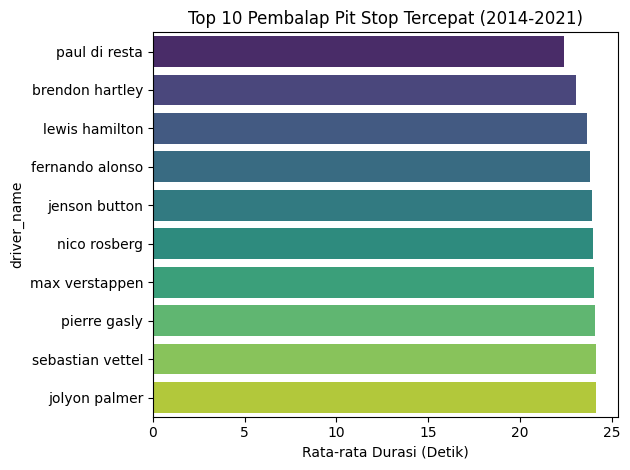

constructor_name
mercedes          23.880
red bull          23.966
aston martin      24.020
mclaren           24.157
ferrari           24.169
alpine f1 team    24.251
renault           24.356
williams          24.361
toro rosso        24.525
force india       24.558
Name: pit_duration_sec, dtype: float64


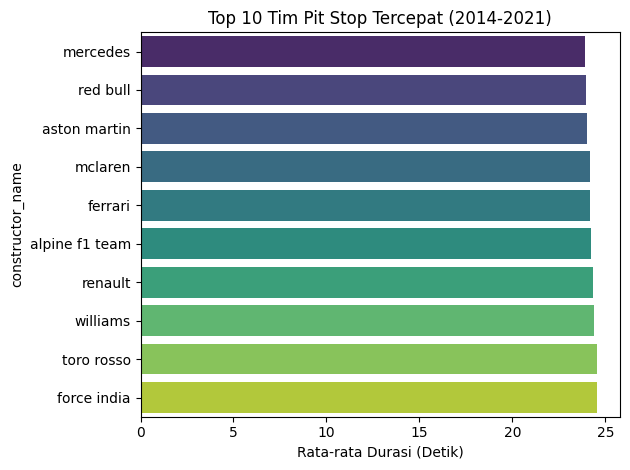

                  pit_duration_sec  positionOrder  points
pit_duration_sec             1.000          0.116  -0.109
positionOrder                0.116          1.000  -0.856
points                      -0.109         -0.856   1.000


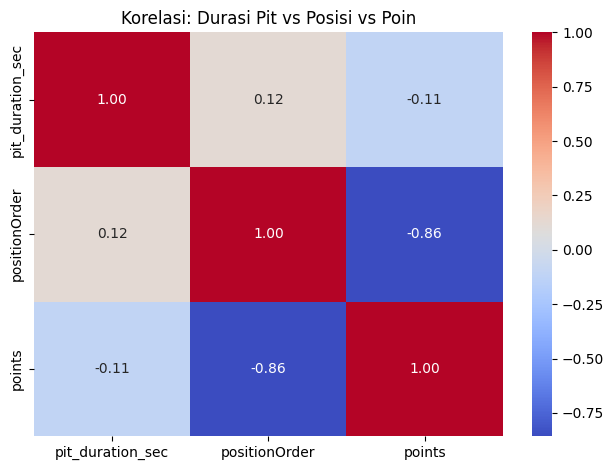

In [ ]:
class PerformanceAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self.df['driver_name'] = self.df['forename'] + ' ' + self.df['surname']

    def top_pit(self, by='driver_name', n=10):
        return self.df.groupby(by)['pit_duration_sec'].mean().nsmallest(n)

    def plot_top(self, by='driver_name', n=10, title=''):
        data = self.top_pit(by, n)
        print(data.round(3))
        sns.barplot(x=data.values, y=data.index, hue=data.index, palette='viridis', legend=False)
        plt.title(title)
        plt.xlabel('Rata-rata Durasi (Detik)')
        plt.tight_layout(); plt.show()

    def analyze_correlations(self):
        corr = self.df[['pit_duration_sec', 'positionOrder', 'points']].corr()
        print(corr.round(3))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Korelasi: Durasi Pit vs Posisi vs Poin')
        plt.tight_layout(); plt.show()

# Penggunaan
analyzer = PerformanceAnalyzer(f1_master)
analyzer.plot_top('driver_name', title='Top 10 Pembalap Pit Stop Tercepat (2014-2021)')
analyzer.plot_top('constructor_name', title='Top 10 Tim Pit Stop Tercepat (2014-2021)')
analyzer.analyze_correlations()

## 7. Algoritma 3: Strategi Pit Stop Optimal

**Tujuan:** Mengidentifikasi strategi jumlah pit stop yang paling sering menghasilkan hasil balapan yang kompetitif pada berbagai sirkuit Formula 1.

**Deskripsi:** Bagian ini akan menganalisis data untuk menemukan pola jumlah pit stop (1-stop, 2-stop, 3+ stop) yang paling sering dikaitkan dengan hasil balapan yang baik, serta membandingkan efektivitas strategi ini di sirkuit-sirkuit populer.

Rata-rata Poin: 5.63 | Rata-rata Posisi: 9.95
Rata-rata Poin: 5.65 | Rata-rata Posisi: 9.75
  strategy  avg_points  avg_position  count
0   1 Stop    5.627119      9.952381   1239
1   2 Stop    5.649863      9.751604   1091
2  3+ Stop    4.502347     10.685446    639
Terbaik (poin): 2 Stop (5.65)
Terbaik (posisi): 2 Stop (9.75)


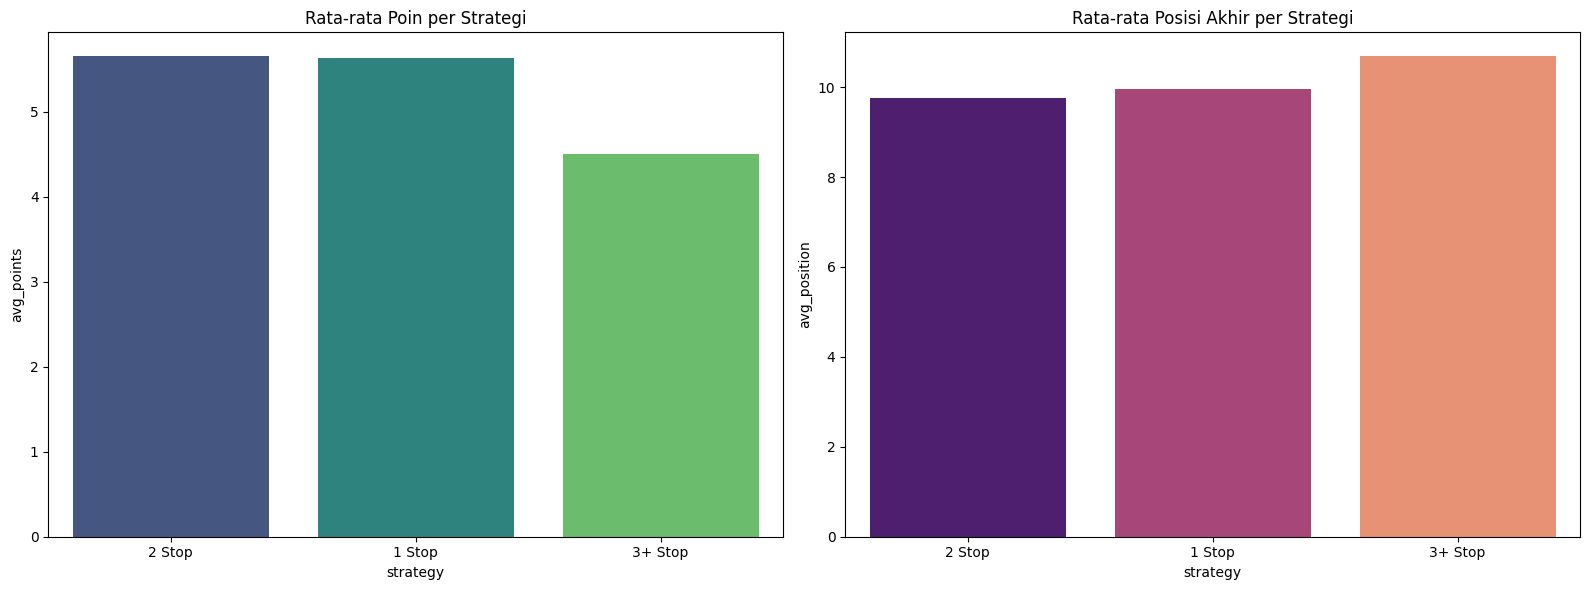

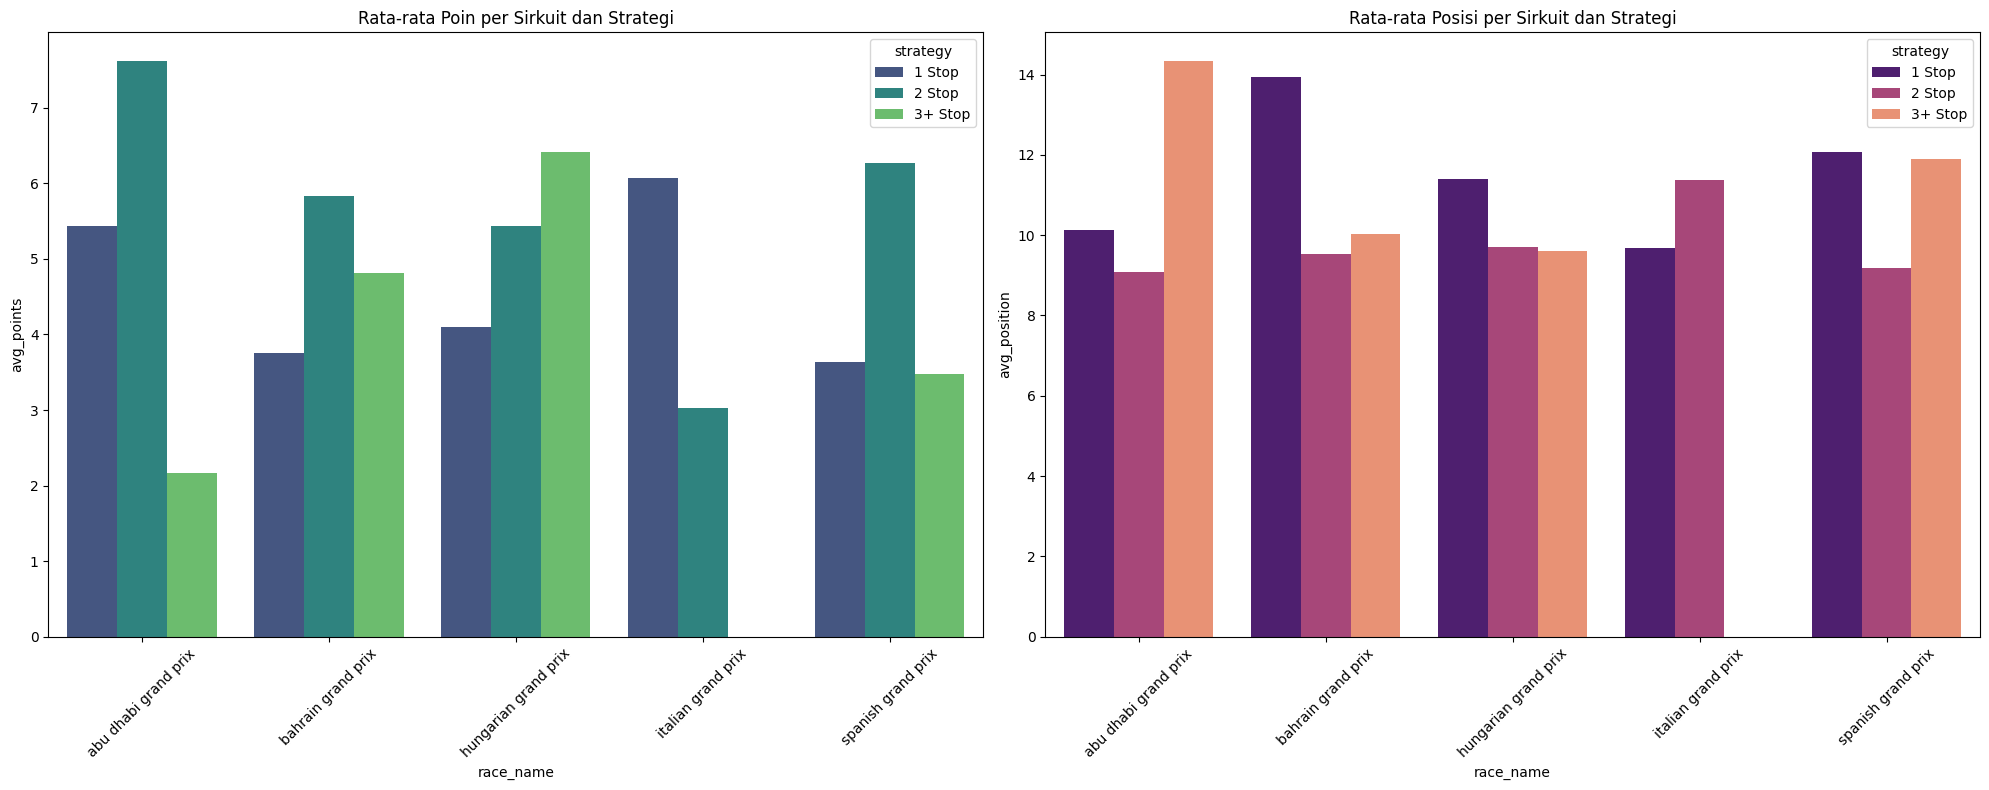

In [ ]:
class StopDataProcessor:
    def __init__(self, df_master):
        self.df_master = df_master.copy()

    def process(self):
        stops = self.df_master.groupby(["raceId", "driverId"])["stop"].max().reset_index()
        stops.rename(columns={"stop": "total_stops"}, inplace=True)

        self.df_master['driver_name'] = self.df_master['forename'] + ' ' + self.df_master['surname']
        info = self.df_master[["raceId", "driverId", "positionOrder", "points", "constructor_name", "driver_name", "race_name"]].drop_duplicates(["raceId", "driverId"])

        df = stops.merge(info, on=["raceId", "driverId"])
        df["strategy"] = df["total_stops"].apply(lambda n: f"{n} Stop" if n <= 2 else "3+ Stop")
        return df

class StrategyAnalyzer:
    def __init__(self, df):
        self.df = df

    def summary(self, num_stops=None):
        data = self.df if num_stops is None else self.df[self.df['total_stops'] == num_stops]
        if data.empty:
            print(f"Tidak ada data untuk {num_stops} Stop.")
            return
        print(f"Rata-rata Poin: {data['points'].mean():.2f} | Rata-rata Posisi: {data['positionOrder'].mean():.2f}")

    def rekomendasi(self):
        perf = self.df.groupby('strategy').agg(avg_points=('points', 'mean'), avg_position=('positionOrder', 'mean'), count=('strategy', 'count')).reset_index()
        print(perf)
        best_points = perf.loc[perf['avg_points'].idxmax()]
        best_position = perf.loc[perf['avg_position'].idxmin()]
        print(f"Terbaik (poin): {best_points['strategy']} ({best_points['avg_points']:.2f})")
        print(f"Terbaik (posisi): {best_position['strategy']} ({best_position['avg_position']:.2f})")
        return perf

    def plot_perbandingan(self, perf):
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sns.barplot(x='strategy', y='avg_points', data=perf.sort_values('avg_points', ascending=False),
                    hue='strategy', ax=axes[0], palette='viridis', legend=False)
        axes[0].set_title('Rata-rata Poin per Strategi')
        sns.barplot(x='strategy', y='avg_position', data=perf.sort_values('avg_position'),
                    hue='strategy', ax=axes[1], palette='magma', legend=False)
        axes[1].set_title('Rata-rata Posisi Akhir per Strategi')
        plt.tight_layout(); plt.show()

    def plot_sirkuit(self, min_count=10, top_n=5):
        cs = self.df.groupby(['race_name', 'strategy']).agg(
            avg_points=('points', 'mean'), avg_position=('positionOrder', 'mean'),
            count=('strategy', 'count')).reset_index()
        cs = cs[cs['count'] >= min_count]
        top_circuits = self.df['race_name'].value_counts().head(top_n).index
        cs = cs[cs['race_name'].isin(top_circuits)]
        if cs.empty:
            return

        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        sns.barplot(x='race_name', y='avg_points', hue='strategy', data=cs, ax=axes[0], palette='viridis')
        axes[0].set_title('Rata-rata Poin per Sirkuit dan Strategi'); axes[0].tick_params(axis='x', rotation=45)
        sns.barplot(x='race_name', y='avg_position', hue='strategy', data=cs, ax=axes[1], palette='magma')
        axes[1].set_title('Rata-rata Posisi per Sirkuit dan Strategi'); axes[1].tick_params(axis='x', rotation=45)
        plt.tight_layout(); plt.show()


# Penggunaan
stop_df = StopDataProcessor(f1_master).process()
analyzer = StrategyAnalyzer(stop_df)

analyzer.summary(1)
analyzer.summary(2)

perf = analyzer.rekomendasi()
analyzer.plot_perbandingan(perf)
analyzer.plot_sirkuit()